In [ ]:
# === Helpers shared by original triptych overlay and the new plots ===
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
from matplotlib.collections import LineCollection
from matplotlib import gridspec
from scipy.spatial import cKDTree
from scipy.stats import median_abs_deviation, spearmanr


def pcolormesh_pad(X, Y):
    Xc = np.pad(X, ((0, 1), (0, 1)), mode="edge")
    Yc = np.pad(Y, ((0, 1), (0, 1)), mode="edge")
    return Xc, Yc


def _boundary_segments_from_mask(mask: np.ndarray, Xc: np.ndarray, Yc: np.ndarray):
    T, S = mask.shape
    segs_xy, segs_idx = [], []

    # internal vertical edges
    vdiff = mask[:, 1:] != mask[:, :-1]
    iv, jv = np.nonzero(vdiff)
    jline = jv + 1
    for i, j in zip(iv, jline):
        a = (i, j)
        b = (i + 1, j)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # outer left and right
    i_left = np.nonzero(mask[:, 0])[0]
    for i in i_left:
        a = (i, 0)
        b = (i + 1, 0)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    i_right = np.nonzero(mask[:, -1])[0]
    for i in i_right:
        a = (i, S)
        b = (i + 1, S)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # internal horizontal edges
    hdiff = mask[1:, :] != mask[:-1, :]
    ih, jh = np.nonzero(hdiff)
    iline = ih + 1
    for i, j in zip(iline, jh):
        a = (i, j)
        b = (i, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    # outer top and bottom
    j_top = np.nonzero(mask[0, :])[0]
    for j in j_top:
        a = (0, j)
        b = (0, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    j_bot = np.nonzero(mask[-1, :])[0]
    for j in j_bot:
        a = (T, j)
        b = (T, j + 1)
        segs_idx.append((a, b))
        segs_xy.append([[Xc[a], Yc[a]], [Xc[b], Yc[b]]])

    return np.asarray(segs_xy, float), segs_idx


def _trace_loops_from_segments(segs_idx):
    adj = {}
    for a, b in segs_idx:
        adj.setdefault(a, []).append(b)
        adj.setdefault(b, []).append(a)

    unvisited = set(frozenset((a, b)) for a, b in segs_idx)
    loops = []

    while unvisited:
        e = unvisited.pop()
        a, b = tuple(e)
        loop = [a, b]
        prev, cur = a, b
        while True:
            nbrs = adj.get(cur, [])
            nxt = next((n for n in nbrs if n != prev), None)
            if nxt is None:
                break
            edge = frozenset((cur, nxt))
            if edge in unvisited:
                unvisited.remove(edge)
            loop.append(nxt)
            prev, cur = cur, nxt
            if nxt == loop[0]:
                break
        loops.append(loop)

        # clean remaining edges of this loop
        for i in range(len(loop) - 1):
            unvisited.discard(frozenset((loop[i], loop[i + 1])))

    return loops


def _compound_path_from_loops(loops, Xc, Yc) -> MplPath:
    paths = []
    for ring in loops:
        xs = [Xc[idx] for idx in ring]
        ys = [Yc[idx] for idx in ring]
        if xs[0] != xs[-1] or ys[0] != ys[-1]:
            xs.append(xs[0])
            ys.append(ys[0])
        verts = np.column_stack([xs, ys])
        codes = np.full(len(verts), MplPath.LINETO, dtype=MplPath.code_type)
        codes[0] = MplPath.MOVETO
        codes[-1] = MplPath.CLOSEPOLY
        paths.append(MplPath(verts, codes))
    if len(paths) == 1:
        return paths[0]
    if len(paths) == 0:
        raise RuntimeError("Footprint loops are empty")
    return MplPath.make_compound_path(*paths)


def _robust_z(a):
    finite = np.isfinite(a)
    if not np.any(finite):
        return np.full_like(a, np.nan, dtype=float)
    m = np.nanmedian(a)
    mad = median_abs_deviation(a[finite], scale="normal")
    if not np.isfinite(mad) or mad == 0:
        mad = 1.0
    return (a - m) / mad


def _robust_sym_vlim(arr, q=0.98):
    m = np.isfinite(arr)
    if not m.any():
        return (-1, 1)
    lo, hi = np.nanquantile(arr[m], [(1 - q) / 2, 1 - (1 - q) / 2])
    vmax_ = max(abs(lo), abs(hi))
    if not np.isfinite(vmax_) or vmax_ == 0:
        vmax_ = (np.nanstd(arr[m]) or 1.0) * 3
    return (-vmax_, vmax_)


# === Original monkey-patch: unchanged behavior, black outline on Residuals ===
def _plot_triptych_with_uhi_overlay(
    self,
    cmap_orig="terrain",
    cmap_resid="RdBu_r",
    figsize=(12, 6),
    crop_to_data=True,
    bounds_percentile=99.5,
    margin_frac=0.03,
    equal_aspect=False,
    show=True,
    *,
    uhi_footprint=None,  # (E, N, valid_mask)
):
    assert self.trend is not None, "Run detrend() first."

    if self.coord_system.lower() == "ned":
        xlabel, ylabel = "East (m)", "North (m)"
    else:
        xlabel, ylabel = "Easting (m)", "Northing (m)"

    def _pad_limits(ax, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=False):
        xr = max(1e-12, x_max - x_min)
        yr = max(1e-12, y_max - y_min)
        ax.set_xlim(x_min - xr * pad_frac, x_max + xr * pad_frac)
        ax.set_ylim(y_min - yr * pad_frac, y_max + yr * pad_frac)
        if equal_aspect:
            ax.set_aspect("equal", adjustable="box")

    # figure and three panels
    fig, axs = plt.subplots(
        1, 3, figsize=figsize, constrained_layout=True, num="MBES Triptych"
    )

    im0 = axs[0].imshow(
        np.ma.masked_invalid(self.data),
        extent=(self.extent[0], self.extent[1], self.extent[2], self.extent[3]),
        origin="upper",
        cmap=cmap_orig,
    )
    axs[0].set_title("Original")
    axs[0].set_xlabel(xlabel)
    axs[0].set_ylabel(ylabel)
    plt.colorbar(im0, ax=axs[0], label="Depth (m)", fraction=0.035, pad=0.02)

    im1 = axs[1].imshow(
        np.ma.masked_invalid(self.trend),
        extent=(self.extent[0], self.extent[1], self.extent[2], self.extent[3]),
        origin="upper",
        cmap=cmap_orig,
    )
    ord_label = (
        2
        if (
            getattr(self, "C_s", None) is not None
            and np.nanmax(np.abs(self.C_s)) > 1e-3
        )
        else 1
    )
    axs[1].set_title(
        f"Estimated trend\norder={ord_label}, base={self.smooth_baseline_m:.2f}m, tilt={self.smooth_tilt_m:.2f}m",
        fontsize=10,
    )
    axs[1].set_xlabel(xlabel)
    axs[1].set_ylabel(ylabel)
    plt.colorbar(im1, ax=axs[1], label="Depth (m)", fraction=0.035, pad=0.02)

    vmin, vmax = _robust_sym_vlim(self.residuals, q=0.98)
    im2 = axs[2].imshow(
        np.ma.masked_invalid(self.residuals),
        extent=(self.extent[0], self.extent[1], self.extent[2], self.extent[3]),
        origin="upper",
        cmap=cmap_resid,
        vmin=vmin,
        vmax=vmax,
        zorder=1,
    )
    axs[2].set_title("Residuals, local variations")
    axs[2].set_xlabel(xlabel)
    axs[2].set_ylabel(ylabel)
    plt.colorbar(im2, ax=axs[2], label="m", fraction=0.035, pad=0.02)

    # crop window
    if crop_to_data and np.isfinite(self.data).any():
        rows, cols = np.where(np.isfinite(self.data))
        p_lo = (100 - bounds_percentile) / 2
        p_hi = 100 - p_lo
        c0 = int(np.percentile(cols, p_lo))
        c1 = int(np.percentile(cols, p_hi))
        r0 = int(np.percentile(rows, p_lo))
        r1 = int(np.percentile(rows, p_hi))
        x_min, x_max = self.x_cols[c0], self.x_cols[c1]
        y_min, y_max = self.y_rows[r1], self.y_rows[r0]
    else:
        x_min, x_max, y_min, y_max = (
            self.extent[0],
            self.extent[1],
            self.extent[2],
            self.extent[3],
        )

    # overlay UHI footprint outline on residuals
    if uhi_footprint is not None:
        if isinstance(uhi_footprint, tuple) and len(uhi_footprint) == 3:
            E, N, valid_mask = uhi_footprint
            Xc, Yc = pcolormesh_pad(E, N)
            segs_xy, segs_idx = _boundary_segments_from_mask(valid_mask, Xc, Yc)
            loops = _trace_loops_from_segments(segs_idx)
            comp_path = _compound_path_from_loops(loops, Xc, Yc)
            outline = PathPatch(
                comp_path,
                transform=axs[2].transData,
                facecolor="none",
                edgecolor="black",
                linewidth=2.0,
                zorder=10,
                alpha=1.0,
            )
            axs[2].add_patch(outline)
        else:
            raise TypeError("uhi_footprint must be (E, N, valid_mask)")

    for ax in axs:
        _pad_limits(
            ax,
            x_min,
            x_max,
            y_min,
            y_max,
            pad_frac=margin_frac,
            equal_aspect=equal_aspect,
        )

    if show:
        plt.show(block=False)
    return fig


# Apply monkey-patch using your project class
sys.path.append(os.path.abspath("../"))
try:
    MBESDetrender
except NameError:
    from utils.other.detrend_mbes import MBESDetrender
MBESDetrender.plot_triptych = _plot_triptych_with_uhi_overlay
print("✅ Monkey-patch applied successfully, black outline only on residuals.")


# === New utilities: Figure 6 (UHI, MBES, Δz) and Figure 7 (metrics) ===
def build_uhi_mbes_products(E, N, mask_valid, uhi_corr_band, mb_obj):
    """
    Inputs:
      E, N, mask_valid: UHI footprint arrays (track sliced)
      uhi_corr_band   : illumination corrected UHI, single band (same shape as E)
      mb_obj          : MBESDetrender already loaded and detrended with coord_system='ned'
    Returns dict with footprint path, inside mask, resampled UHI on MBES grid, z-scores and extents.
    """
    # footprint path from UHI grid
    Xc_uhi, Yc_uhi = pcolormesh_pad(E, N)
    segs_xy, segs_idx = _boundary_segments_from_mask(mask_valid, Xc_uhi, Yc_uhi)
    loops = _trace_loops_from_segments(segs_idx)
    footprint_path = _compound_path_from_loops(loops, Xc_uhi, Yc_uhi)

    # MBES grid in NED directly from mb_obj
    MBES_E, MBES_N = np.meshgrid(mb_obj.x_cols, mb_obj.y_rows)
    extent_ned = [
        np.nanmin(MBES_E),
        np.nanmax(MBES_E),
        np.nanmin(MBES_N),
        np.nanmax(MBES_N),
    ]

    # which MBES pixels are inside the UHI footprint
    pts_mbes = np.column_stack([MBES_E.ravel(), MBES_N.ravel()])
    inside = footprint_path.contains_points(pts_mbes).reshape(MBES_E.shape)
    if not np.any(inside):
        raise RuntimeError("No MBES pixels inside UHI footprint, check NED alignment.")

    # resample UHI to MBES grid, nearest neighbor, only inside
    valid_uhi = (
        mask_valid & np.isfinite(uhi_corr_band) & np.isfinite(E) & np.isfinite(N)
    )
    uhi_on_mbes = np.full_like(mb_obj.residuals, np.nan, dtype=float)
    if np.any(valid_uhi):
        uhi_pts = np.column_stack([E[valid_uhi], N[valid_uhi]])
        uhi_vals = uhi_corr_band[valid_uhi]
        tree = cKDTree(uhi_pts)
        idx_inside = np.where(inside.ravel())[0]
        d, nn = tree.query(pts_mbes[idx_inside], k=1)
        flat = uhi_on_mbes.ravel()
        flat[idx_inside] = uhi_vals[nn]
        uhi_on_mbes = flat.reshape(mb_obj.residuals.shape)

    # standardized z-scores and diff
    mbes_in = np.where(inside, mb_obj.residuals, np.nan)
    uhi_in = np.where(inside, uhi_on_mbes, np.nan)
    z_mbes = _robust_z(mbes_in)
    z_uhi = _robust_z(uhi_in)
    diff_z = z_uhi - z_mbes

    # vlims
    finite_diff = np.isfinite(diff_z)
    vmax_diff = (
        np.nanpercentile(np.abs(diff_z[finite_diff]), 98.0)
        if np.any(finite_diff)
        else 1.0
    )
    vmin_diff = -vmax_diff
    vmin_mbes, vmax_mbes = _robust_sym_vlim(mb_obj.residuals, q=0.98)

    # tight footprint bbox for equal aspect pads
    xs_outline = footprint_path.vertices[:, 0]
    ys_outline = footprint_path.vertices[:, 1]
    x_min, x_max = np.nanmin(xs_outline), np.nanmax(xs_outline)
    y_min, y_max = np.nanmin(ys_outline), np.nanmax(ys_outline)

    return dict(
        footprint_path=footprint_path,
        segs_xy=segs_xy,
        extent_ned=extent_ned,
        inside=inside,
        uhi_on_mbes=uhi_on_mbes,
        z_mbes=z_mbes,
        z_uhi=z_uhi,
        diff_z=diff_z,
        vmin_diff=vmin_diff,
        vmax_diff=vmax_diff,
        vmin_mbes=vmin_mbes,
        vmax_mbes=vmax_mbes,
        x_min=x_min,
        x_max=x_max,
        y_min=y_min,
        y_max=y_max,
        MBES_residuals=mb_obj.residuals,
        UHI_corr_band=uhi_corr_band,
        E=E,
        N=N,
        mask_valid=mask_valid,
    )


def figure6_uhi_mbes_dz(products):
    """Three panel plot: UHI corrected, MBES residuals, Δz standardized, all in NED."""
    fp = products["footprint_path"]
    segs_xy = products["segs_xy"]
    extent_ned = products["extent_ned"]
    x_min, x_max = products["x_min"], products["x_max"]
    y_min, y_max = products["y_min"], products["y_max"]

    # UHI inputs
    E = products["E"]
    N = products["N"]
    mask_valid = products["mask_valid"]
    uhi_corr = products["UHI_corr_band"]
    Xc_show, Yc_show = pcolormesh_pad(E, N)

    # MBES inputs
    mb_res = products["MBES_residuals"]
    vmin_mbes, vmax_mbes = products["vmin_mbes"], products["vmax_mbes"]

    # diff
    diff_z = products["diff_z"]
    vmin_diff, vmax_diff = products["vmin_diff"], products["vmax_diff"]

    fig = plt.figure(
        constrained_layout=True, figsize=(20, 6.5), num="Figure 6: UHI, MBES, Δz (NED)"
    )
    gs = gridspec.GridSpec(ncols=3, nrows=1, figure=fig, width_ratios=[1, 1, 1])

    axU = fig.add_subplot(gs[0, 0])
    uhi_plot = uhi_corr.copy()
    uhi_plot[~mask_valid] = np.nan
    im_uhi = axU.pcolormesh(Xc_show, Yc_show, uhi_plot, shading="flat", cmap="viridis")
    im_uhi.set_clip_path(PathPatch(fp, transform=axU.transData, facecolor="none"))
    if len(segs_xy) > 0:
        axU.add_collection(
            LineCollection(segs_xy, colors="k", linewidths=1.0, alpha=0.9)
        )
    _set_box(axU, x_min, x_max, y_min, y_max)
    axU.set_title("UHI illumination corrected, NED")
    axU.set_xlabel("East (m)")
    axU.set_ylabel("North (m)")
    plt.colorbar(im_uhi, ax=axU, fraction=0.045, pad=0.02, label="UHI (a.u.)")

    axM = fig.add_subplot(gs[0, 1])
    im_mbes = axM.imshow(
        np.ma.masked_invalid(mb_res),
        extent=extent_ned,
        origin="upper",
        cmap="RdBu_r",
        vmin=vmin_mbes,
        vmax=vmax_mbes,
    )
    im_mbes.set_clip_path(PathPatch(fp, transform=axM.transData, facecolor="none"))
    _set_box(axM, x_min, x_max, y_min, y_max)
    axM.set_title("MBES residuals, NED")
    axM.set_xlabel("East (m)")
    axM.set_ylabel("North (m)")
    plt.colorbar(im_mbes, ax=axM, fraction=0.045, pad=0.02, label="MBES Residuals (m)")

    axD = fig.add_subplot(gs[0, 2])
    im_diff = axD.imshow(
        np.ma.masked_invalid(diff_z),
        extent=extent_ned,
        origin="upper",
        cmap="RdBu_r",
        vmin=products["vmin_diff"],
        vmax=products["vmax_diff"],
    )
    im_diff.set_clip_path(PathPatch(fp, transform=axD.transData, facecolor="none"))
    _set_box(axD, x_min, x_max, y_min, y_max)
    axD.set_title("Δz standardized, UHI minus MBES, NED")
    axD.set_xlabel("East (m)")
    axD.set_ylabel("North (m)")
    plt.colorbar(im_diff, ax=axD, fraction=0.045, pad=0.02, label="Δz")

    plt.show()
    return fig


def figure7_metrics(products):
    """Scatter, Bland Altman, histogram, with printed metrics."""
    z_mbes = products["z_mbes"]
    z_uhi = products["z_uhi"]
    inside = products["diff_z"] * 0 + 1  # not used directly, kept for parity
    valid_pairs = np.isfinite(z_mbes) & np.isfinite(z_uhi)
    zM = z_mbes[valid_pairs].ravel()
    zU = z_uhi[valid_pairs].ravel()
    Dz = zU - zM

    if zM.size == 0:
        raise RuntimeError("No overlapping valid samples to compute metrics")

    pearson_r = float(np.corrcoef(zM, zU)[0, 1]) if zM.size > 1 else np.nan
    spearman_rho = (
        float(spearmanr(zM, zU, nan_policy="omit").correlation)
        if zM.size > 1
        else np.nan
    )
    b, a = np.polyfit(zM, zU, 1) if zM.size > 1 else (np.nan, np.nan)
    r2 = float(pearson_r**2) if np.isfinite(pearson_r) else np.nan
    rmse = float(np.sqrt(np.nanmean((zU - zM) ** 2)))
    mae = float(np.nanmean(np.abs(Dz)))
    median_dz = float(np.nanmedian(Dz))
    mad_dz = float(median_abs_deviation(Dz, scale="normal"))
    # footprint coverage numbers
    n_inside = int(np.isfinite(products["diff_z"]).size)
    n_valid_both = int(zM.size)
    coverage_pct = 100.0 * n_valid_both / max(1, n_inside)

    print("----- UHI vs MBES metrics (z units; inside UHI footprint) -----")
    print(f"valid in both (coverage)        : {n_valid_both:,}  ({coverage_pct:.1f}%)")
    print(f"Pearson r / Spearman rho        : {pearson_r:.3f} / {spearman_rho:.3f}")
    print(f"Linear fit (zU = a + b*zM)      : a={a:.3f}, b={b:.3f}, R^2={r2:.3f}")
    print(f"Δz = zU − zM: median/MAD        : {median_dz:.3f} / {mad_dz:.3f}")
    print(f"Δz RMSE / MAE                   : {rmse:.3f} / {mae:.3f}")
    print("---------------------------------------------------------------\n")

    fig = plt.figure(
        constrained_layout=True,
        figsize=(18, 5.8),
        num="Figure 7: Metrics and Diagnostics",
    )
    gs = gridspec.GridSpec(ncols=3, nrows=1, figure=fig, width_ratios=[1.2, 1.2, 1.0])

    # density scatter with 1:1 and regression
    axA = fig.add_subplot(gs[0, 0])
    hb = axA.hexbin(zM, zU, gridsize=80, mincnt=1, cmap="viridis")
    lim = float(
        np.clip(
            np.nanmax(
                np.abs(
                    [np.nanmin([zM.min(), zU.min()]), np.nanmax([zM.max(), zU.max()])]
                )
            ),
            2.0,
            6.0,
        )
    )
    axA.plot([-lim, lim], [-lim, lim], "k--", lw=1.2, label="1:1")
    axA.plot(
        [-lim, lim],
        [a + b * (-lim), a + b * (lim)],
        "r-",
        lw=1.3,
        label=f"fit  b={b:.2f}",
    )
    axA.set_xlim(-lim, lim)
    axA.set_ylim(-lim, lim)
    axA.set_xlabel("z(MBES residuals)")
    axA.set_ylabel("z(UHI corrected)")
    axA.set_title("Density scatter in z units")
    cb = plt.colorbar(hb, ax=axA, fraction=0.045, pad=0.02)
    cb.set_label("count")
    axA.legend(loc="lower right")

    # Bland Altman
    axB = fig.add_subplot(gs[0, 1])
    mean_z = 0.5 * (zU + zM)
    axB.hexbin(mean_z, Dz, gridsize=80, mincnt=1, cmap="coolwarm")
    axB.axhline(0.0, color="k", lw=1.0)
    axB.axhline(
        median_dz, color="k", lw=1.0, ls="--", label=f"median Δz={median_dz:.2f}"
    )
    axB.axhline(median_dz + 1.4826 * mad_dz, color="gray", lw=1.0, ls=":")
    axB.axhline(median_dz - 1.4826 * mad_dz, color="gray", lw=1.0, ls=":")
    axB.set_xlabel("mean of z(UHI) and z(MBES)")
    axB.set_ylabel("Δz = z(UHI) minus z(MBES)")
    axB.set_title("Bland Altman with robust lines")
    axB.legend(loc="upper left")

    # histogram
    axC = fig.add_subplot(gs[0, 2])
    bins = np.linspace(-3.5, 3.5, 70)
    axC.hist(Dz, bins=bins, density=True, alpha=0.85)
    axC.axvline(0.0, color="k", lw=1.0)
    for thr, col in [(0.5, "tab:green"), (1.0, "tab:orange"), (2.0, "tab:red")]:
        axC.axvline(+thr, color=col, lw=1.0, ls="--")
        axC.axvline(-thr, color=col, lw=1.0, ls="--")
    axC.set_xlabel("Δz")
    axC.set_ylabel("pdf")
    axC.set_title("Δz distribution")
    txt = (
        f"n valid both     : {n_valid_both:,} ({coverage_pct:.1f}%)\n"
        f"Pearson, Spearman: {pearson_r:.3f}, {spearman_rho:.3f}\n"
        f"fit a, b (R^2)   : {a:.2f}, {b:.2f}  ({r2:.2f})\n"
        f"RMSE, MAE (Δz)   : {rmse:.2f}, {mae:.2f}\n"
        f"median, MAD      : {median_dz:.2f}, {mad_dz:.2f}\n"
    )
    axC.text(
        0.97,
        0.97,
        txt,
        transform=axC.transAxes,
        va="top",
        ha="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
        fontsize=9,
    )

    plt.show()
    return fig


def _set_box(ax, x_min, x_max, y_min, y_max, pad_frac=0.03):
    xr = max(1e-12, x_max - x_min)
    yr = max(1e-12, y_max - y_min)
    ax.set_xlim(x_min - xr * pad_frac, x_max + xr * pad_frac)
    ax.set_ylim(y_min - yr * pad_frac, y_max + yr * pad_frac)
    ax.set_aspect("equal", adjustable="box")

NameError: name 'sys' is not defined

📂 Loading UHI transect data...
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_4
  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (4925, 968), RGB (4925, 968)
📊 Extracting tracks 3039 to 4029...
✅ UHI Footprint: E shape=(990, 968), N shape=(990, 968)
   Valid pixels: 958,320 / 958,320 (100.0%)

🗺️  Loading and detrending MBES data in NED...

🎨 Plotting MBES triptych with UHI footprint outline (original behavior)...


AttributeError: 'QuadContourSet' object has no attribute 'collections'

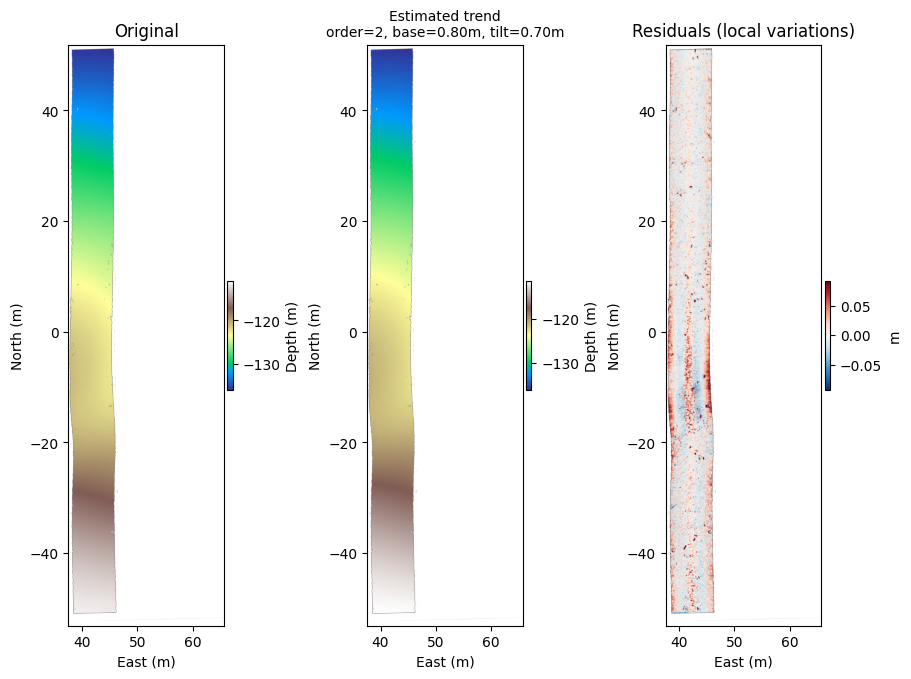

In [4]:
# Keep your original imports style
import sys, os
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../"))

from utils.other.detrend_mbes import MBESDetrender
from utils.gref_pipeline import georef
from utils.gref_pipeline.georef import _ecef_to_ned_arrays
from gref_pipeline import config


# Your original helper
def build_full_valid_mask(X_ecef, Y_ecef, Z_ecef, R, G, B):
    coords_valid = np.isfinite(X_ecef) & np.isfinite(Y_ecef) & np.isfinite(Z_ecef)
    rgb_valid = np.isfinite(R) & np.isfinite(G) & np.isfinite(B)
    return coords_valid & rgb_valid


print("📂 Loading UHI transect data...")
transect = georef.load_transect(config.OUTPUT_FOLDER)
cube = transect.select_files(
    [
        "rad_uhi_20241029_115057_4",
        "rad_uhi_20241029_115057_5",
    ]
)

# Track slice identical to your working range
track_start = 3039
track_end = 4029
print(f"📊 Extracting tracks {track_start} to {track_end}...")

# UHI ECEF and RGB
X_ecef = cube.X_ecef[track_start:track_end, :]
Y_ecef = cube.Y_ecef[track_start:track_end, :]
Z_ecef = cube.Z_ecef[track_start:track_end, :]
R = cube.R[track_start:track_end, :]
G = cube.G[track_start:track_end, :]
B = cube.B[track_start:track_end, :]

full_valid = build_full_valid_mask(X_ecef, Y_ecef, Z_ecef, R, G, B)

# UHI to NED
lat0, lon0, h0 = config.LAT0, config.LON0, config.H0
N, E, _ = _ecef_to_ned_arrays(X_ecef, Y_ecef, Z_ecef, lat0, lon0, h0)
print(f"✅ UHI Footprint: E shape={E.shape}, N shape={N.shape}")
print(
    f"   Valid pixels: {full_valid.sum():,} / {full_valid.size:,} ({100*full_valid.mean():.1f}%)"
)

print("\n🗺️  Loading and detrending MBES data in NED...")
mb_ned = (
    MBESDetrender(
        config.MBES_GEOTIFF,
        coord_system="ned",
        ned_origin=(config.LON0, config.LAT0, config.H0),
        epsg_utm=config.EPSG_UTM,
        epsg_geo=config.EPSG_GEOGRAPHIC,
    )
    .load()
    .detrend(
        order_x=3,
        smooth_baseline_m=0.80,
        smooth_tilt_m=0.70,
        smooth_center_m=1.0,
        robust=True,
        central_frac=0.8,
    )
)

print("\n🎨 Plotting MBES triptych with UHI footprint outline (original behavior)...")
_ = mb_ned.plot_triptych(uhi_footprint=(E, N, full_valid), show=True)

# New: illumination correction and green band for UHI
cube.apply_illumination_correction(window_size=1000, strength=1.0)
wavelengths = cube.wavelengths
idx_green = int(np.argmin(np.abs(wavelengths - 560.0)))
uhi_corr = cube.data_corrected[track_start:track_end, :, idx_green]

# Build shared products once
print("\n🆕 Building UHI and MBES alignment products for new plots...")
products = build_uhi_mbes_products(E, N, full_valid, uhi_corr, mb_ned)

print("\n🖼️  Figure 6: UHI, MBES, Δz (NED)")
_ = figure6_uhi_mbes_dz(products)

print("\n📈 Figure 7: Metrics and diagnostics")
_ = figure7_metrics(products)

print("✅ Done.")